In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO

In [86]:
class OvercookedKitchen(gym.Env):
    def __init__(self, layout):
        self.layout = layout
        self.height = len(layout)
        self.width = len(layout[0])
        self.cooking_surfaces = [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'P']
        count=1
        self.chopping_boards = {}
        for y, row in enumerate(layout):
            for x, tile in enumerate(row):
                if tile == 'C':
                    self.chopping_boards[(x,y)] = f'chop_board_{count}'
                    count += 1
        self.dish_positions = [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'D']
        self.dispensers = {
            'tomato': [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'T'],
            'steak': [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'S'],
            'bread': [(x, y) for y, row in enumerate(layout) for x, tile in enumerate(row) if tile == 'B']
        }
        self.TIME_TO_CHOP = 3
        self.TIME_TO_COOK = 5
        self.TIME_TO_BURN = 5
        self.MAX_ORDERS = 1
        self.MAX_STEPS = 200
        self.MAX_ORDER_TIME = 100
        # Actions : 0-3 Movement, 4 Interact, 5 Chop
        self.action_space = spaces.Discrete(6)
        # Observation space : agent_pos (2), agent_dir (2), held_obj (1), pans_state (number of pans(1) * 3), dishes_state (number of dishes(1) * 4), chopping_boards_state (number of chopping boards(1)), objects_on_counter(24 : layout perimeter), order (first 1 orders*2), timer (1)
        
        obs_size = 0
        # agent position
        obs_size += 2
        # direction one-hot
        obs_size += 4
        # held object encoding
        obs_size += 8
        # pans
        obs_size += len(self.cooking_surfaces) * (2 + 3 + 1)
        # position(2) + status onehot(3) + timer(1)
        # dishes
        obs_size += len(self.dish_positions) * (2 + 3)
        # position(2) + bread/tomato/steak (3)
        # chopping boards
        obs_size += len(self.chopping_boards) * (2 + 1 + 3)
        # position(2) + progress(1) + object encoding(3)
        # ingredient dispensers distances
        obs_size += 3
        # distance nearest pan
        obs_size += 1
        # distance nearest dish
        obs_size += 1

        # time
        obs_size += 1

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(obs_size,),
            dtype=np.float32
        )
        print(f"Observation space size: {obs_size}")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # We reset the timer
        self.step_count = 0
        # We place the agent in the middle of the kitchen, facing downwards
        self.agent_pos = (2, 2)
        self.agent_dir = (0, 1) # Regarde vers le bas
        self.held_obj = None
        self.done = False
        self.nb_active_orders = self.MAX_ORDERS
        self.nb_tomato = 0
        self.nb_steak=0
        self.nb_bread = 0
        
        self.objects_on_counters = {} # {(x, y): obj}
        self.pans_state = {}          # {'pan_1': {'location': (x,y), 'status': 'empty', 'timer': 0}}
        self.dishes = {}              # {'dish_1': {'location': (x,y), 'bread': False, 'tomato': False, 'steak': False}}
        self.chopping_boards_state = {}     # {'chop_board_1' : 0}
        self.orders = {}           # {order_id: {'recipe': 'burger', 'timer': 0}}
        
        for y, row in enumerate(self.layout):
            for x, tile in enumerate(row):
                if x == 0 or x == self.width-1 or y == 0 or y == self.height-1:
                    self.objects_on_counters[(x, y)] = None # We initialize the perimeter of the kitchen as free of objects

        for i in range(len(self.cooking_surfaces)):
            pan_pos = self.cooking_surfaces[i]
            self.pans_state[f'pan_{i}'] = {'location': pan_pos, 'status': 'empty', 'timer': 0}
            self.objects_on_counters[pan_pos] = f'pan_{i}' # We consider the pan as an object on the counter when it's not held by the agent, this will allow us to display it and to interact with it more easily
        
        for i in range(len(self.dish_positions)):
            dish_pos = self.dish_positions[i]
            self.dishes[f'dish_{i}'] = {'location': dish_pos, 'bread': False, 'tomato': False, 'steak': False}
            self.objects_on_counters[dish_pos] = f'dish_{i}' # We consider the dish as an object on the counter when it's not held by the agent, this will allow us to display it and to interact with it more easily
        
        for chop_board in self.chopping_boards.values():
            self.chopping_boards_state[chop_board] = 0 # 0 means empty, otherwise it will represent the chopping progression

        return self._get_obs(), {}

    def render(self):
        grid_copy = [list(row) for row in self.layout]
        
        # We display the objects on the counters (tomatoes, steaks, bread, ) with their first letter in uppercase
        for (x, y), obj in self.objects_on_counters.items():
            if obj is not None:
                char = obj[0].upper()
                grid_copy[y][x] = char
        
        # We display the ingredients dispensers with their corresponding letters
        for ingredient, positions in self.dispensers.items():
            char = ingredient[0].upper()
            for (x, y) in positions:
                grid_copy[y][x] = char
        # We display the agent with an arrow indicating its direction
        ax, ay = self.agent_pos
        dir_map = {(0, -1): '^', (0, 1): 'v', (-1, 0): '<', (1, 0): '>'}
        grid_copy[ay][ax] = dir_map.get(self.agent_dir, 'A')

        # Clean display
        print("\n" + "="*20)
        for row in grid_copy:
            print(" ".join(row))
        print(f"Hand : {self.held_obj}")
        print(f"Pans : {[(p['location'], p['status'], p['timer']) for p in self.pans_state.values()]}")
        print(f"Dishes : {[(d['location'], d['bread'], d['tomato'], d['steak']) for d in self.dishes.values()]}")
        print(f"Chopping boards : {[(c, self.chopping_boards_state[c]) for c in self.chopping_boards_state]}")
        print(f"Objects on counters : {[(pos, obj) for (pos, obj) in self.objects_on_counters.items() if obj is not None]}")
        print(f"Orders: {len([o for o in self.orders.values() if o['recipe'] != 'empty'])} active")
        if self.orders:
            for oid, order in self.orders.items():
                if order['recipe'] != 'empty':
                    print(f"  {oid}: {order['recipe']} (wait: {order['timer']})")
        print(f"Steps: {self.step_count}/{self.MAX_STEPS}")
        print("="*20)
    
    def _get_obs(self):
    
        obs = []
        ax, ay = self.agent_pos

        # Agent position (normalized)

        obs.append(ax / self.width)
        obs.append(ay / self.height)

        # direction one-hot
        dir_vec = [0,0,0,0]  # up down left right

        if self.agent_dir == (0,-1): dir_vec[0] = 1
        elif self.agent_dir == (0,1): dir_vec[1] = 1
        elif self.agent_dir == (-1,0): dir_vec[2] = 1
        elif self.agent_dir == (1,0): dir_vec[3] = 1

        obs.extend(dir_vec)
        # 2. Held object encoding

        held_encoding = [0]*8
        # [none, tomato, steak, bread, chopped_tomato, burger, pan_empty, pan_ready]

        if self.held_obj is None:
            held_encoding[0] = 1

        elif self.held_obj == "tomato":
            held_encoding[1] = 1

        elif self.held_obj == "steak":
            held_encoding[2] = 1

        elif self.held_obj == "bread":
            held_encoding[3] = 1

        elif self.held_obj == "chopped_tomato":
            held_encoding[4] = 1

        elif self.held_obj == "full_burger":
            held_encoding[5] = 1

        elif "pan" in str(self.held_obj):

            pan = self.pans_state[self.held_obj]

            if pan["status"] == "ready":
                held_encoding[7] = 1
            else:
                held_encoding[6] = 1

        obs.extend(held_encoding)

        # 3. Pans state

        for pan in self.pans_state.values():

            px, py = pan["location"]

            # position
            obs.append(px / self.width)
            obs.append(py / self.height)

            # status
            if pan["status"] == "empty":
                obs.extend([1,0,0])
            elif pan["status"] == "cooking":
                obs.extend([0,1,0])
            else:
                obs.extend([0,0,1])

            # cooking progress
            obs.append(pan["timer"] / self.TIME_TO_COOK)

        # Dish state

        for dish in self.dishes.values():

            dx, dy = dish["location"]

            obs.append(dx / self.width)
            obs.append(dy / self.height)

            obs.append(int(dish["bread"]))
            obs.append(int(dish["tomato"]))
            obs.append(int(dish["steak"]))

        # Chopping boards

        for pos, board_id in self.chopping_boards.items():

            x,y = pos

            obs.append(x / self.width)
            obs.append(y / self.height)

            progress = self.chopping_boards_state[board_id] / self.TIME_TO_CHOP
            obs.append(progress)

            obj = self.objects_on_counters.get(pos)

            board_obj = [0,0,0]

            if obj is None:
                board_obj[0] = 1
            elif obj == "tomato":
                board_obj[1] = 1
            elif obj == "chopped_tomato":
                board_obj[2] = 1

            obs.extend(board_obj)

        #  Distances to ingredient dispensers

        for ingredient in ["tomato","steak","bread"]:

            positions = self.dispensers[ingredient]

            dist = min(abs(ax-x)+abs(ay-y) for x,y in positions)

            obs.append(dist / (self.width + self.height))

        
        # 7. Distance to nearest pan
        # -----------------------------

        pan_dist = min(
            abs(ax-pan["location"][0]) + abs(ay-pan["location"][1])
            for pan in self.pans_state.values()
        )

        obs.append(pan_dist / (self.width + self.height))

        # -----------------------------
        # 8. Distance to nearest dish
        # -----------------------------

        dish_dist = min(
            abs(ax-dish["location"][0]) + abs(ay-dish["location"][1])
            for dish in self.dishes.values()
        )

        obs.append(dish_dist / (self.width + self.height))

        # -----------------------------
        # 9. Time
        # -----------------------------

        obs.append(self.step_count / self.MAX_STEPS)

        return np.array(obs, dtype=np.float32)
    
    def _get_adj_pos(self):
        """Calculate the position adjacent to the agent based on its current direction."""
        x, y = self.agent_pos
        dx, dy = self.agent_dir
        return (x + dx, y + dy)

    def step(self, action):
        reward = -0.01 # Survival reward

        ## Cooking progress update (passive cooking)
        for _, pan in self.pans_state.items():
            if pan['status'] == 'cooking' and pan['location'] in self.cooking_surfaces:
                pan['timer'] += 1
                if pan['timer'] >= self.TIME_TO_COOK:
                    pan['status'] = 'ready'
                    if pan['timer'] > self.TIME_TO_COOK:
                            reward -= 0 # Penalty for overcooking, to encourage the agent to pick up the steak once it's ready
                    else:
                         reward += 1.0 # Reward for cooking the steak, to encourage the agent to cook the steak
                if pan['timer'] >= self.TIME_TO_COOK + self.TIME_TO_BURN:
                    pan['status'] = 'empty' # The steak is burned and disappears, we reset the pan
                    pan['timer'] = 0
                    reward -= 0.5 # Penalty for burning the steak
        for oid, order in self.orders.items():
            if order['recipe'] != 'empty':
                order['timer'] += 1
                if order['timer'] >= self.MAX_ORDER_TIME:
                    reward -= 0 # Penalty for not delivering the order in time
        
        if action < 4: # MOVEMENT
            move_reward = self._handle_move(action)
            reward += move_reward
        
        elif action == 4: # INTERACT (Take/Place/Cook)
            target_pos = self._get_adj_pos()
            tile = self.layout[target_pos[1]][target_pos[0]]
            if target_pos in self.dispensers['tomato'] and self.held_obj == None: # If it's an ingredient dispenser, we create the corresponding object instead of picking it up
                self.held_obj = "tomato"
                reward += 0.1 # Small reward for picking up a raw ingredient, to encourage the agent to get ingredients and not just move them around
                self.nb_tomato += 1
                if  self.nb_tomato > self.nb_active_orders:
                    reward -= 0.5 # Penalty for picking up more tomatoes than needed, to encourage the agent to only pick up the ingredients it needs
            elif target_pos in self.dispensers['steak'] and self.held_obj == None:
                self.held_obj = "steak"
                reward += 0.1 # Small reward for picking up a raw ingredient, to encourage the agent to get ingredients and not just move them around
                self.nb_steak += 1
                if  self.nb_steak > self.nb_active_orders:
                    reward -= 0.5 # Penalty for picking up more steaks than needed, to encourage the agent to only pick up the ingredients it needs
            elif target_pos in self.dispensers['bread'] and self.held_obj == None:
                self.held_obj = "bread"
                reward += 0.1    # Small reward for picking up a raw ingredient, to encourage the agent to get ingredients and not just move them around
                self.nb_bread += 1
                if  self.nb_bread > self.nb_active_orders:
                    reward -= 0.5 # Penalty for picking up more bread than needed, to encourage the agent to only pick up the ingredients it needs
            elif tile == 'P': # Pan
                pan_reward = self._handle_pan_interact(target_pos)
                reward += pan_reward
            elif tile == ' ': # Empty Space
                empty_space_reward = self._handle_empty_space_interact(target_pos)
                reward += empty_space_reward
            elif tile == 'D': # Dish
                dish_reward = self._handle_dish_interact(target_pos)
                reward += dish_reward
            elif tile == 'C': # Chopping board
                chopping_board_reward = self._handle_chopping_board_interact(target_pos)
                reward += chopping_board_reward
            elif tile == 'V': # Delivery point
                delivery_reward = self._handle_delivery()
                reward += delivery_reward 
            elif tile == '.': #counter
                counter_reward = self._handle_counter_interact(target_pos)
                reward += counter_reward

        elif action == 5 and self.held_obj == None: # Chop
            target_pos = self._get_adj_pos()
            if self.layout[target_pos[1]][target_pos[0]] == 'C': # Chopping board
                chopping_reward = self._handle_chopping(target_pos)
                reward += chopping_reward


        if len(self.orders) < self.MAX_ORDERS and np.random.random() < 0.1: # We add a new order with a certain probability if we are below the max number of orders
            order_id = f"order_{len(self.orders)}"
            self.orders[order_id] = {'recipe': 'burger', 'timer': 0}

        self.step_count += 1
        if self.step_count >= self.MAX_STEPS:
            self.done = True

        return self._get_obs(), reward, self.done, False, {}
    
    def _handle_move(self, action):
        reward = 0.0
        # We map the action to a direction vector
        # 0: Up, 1: Down, 2: Left, 3: Right
        directions = [(0, -1), (0, 1), (-1, 0), (1, 0)]
        dx, dy = directions[action]
        
        # We update the agent's direction
        self.agent_dir = (dx, dy)
        old_x, old_y = self.agent_pos
        
        new_x = self.agent_pos[0] + dx
        new_y = self.agent_pos[1] + dy
        
        if 0 <= new_x < self.width and 0 <= new_y < self.height:
            # We can only move if the target tile is empty
            if self.layout[new_y][new_x] == ' ':
                self.agent_pos = (new_x, new_y)
            if  'pan' in str(self.held_obj):
                # If we hold a pan, we also move it with us
                pan = self.held_obj
                self.pans_state[pan]['location'] = (new_x, new_y)
        if 'pan' in str(self.held_obj) or self.held_obj == "chopped_tomato" or self.held_obj == "bread" :
            dist_to_dish = min(
                abs(self.agent_pos[0] - dish[0]) + abs(self.agent_pos[1] - dish[1])
                for dish in self.dish_positions

            )
            old_dist_to_dish = min(
                abs(old_x - dish[0]) + abs(old_y - dish[1])
                for dish in self.dish_positions
            )
            if dist_to_dish < old_dist_to_dish:
                reward += 0.01 # Small reward for moving closer to the dish when holding an ingredient or a pan with a cooked steak, to encourage the agent to bring the ingredients to the dish
        return reward # Default reward for moving
    
    def _handle_chopping_board_interact(self, target_pos):
        obj_on_board = self.objects_on_counters.get(target_pos)
        reward = 0.0
        if obj_on_board is None and self.held_obj == "tomato":
            # We put the tomato on the chopping board to start chopping
            self.objects_on_counters[target_pos] = 'tomato'
            self.held_obj = None
            self.chopping_boards_state[self.chopping_boards.get(target_pos)] = 0
            reward += 0.1 # Reward for placing a tomato on the chopping board
        elif obj_on_board == "chopped_tomato" and self.held_obj is None:
            self.held_obj = "chopped_tomato"
            self.objects_on_counters[target_pos] = None
            self.chopping_boards_state[self.chopping_boards.get(target_pos)] = 0 # Reset l'affichage de la planche
            reward += 0.3 # Reward for picking up chopped tomato
        return reward

        # # Optional: we could get the raw tomato back if we interact again while it's still raw
        # elif obj_on_board is not None and obj_on_board['status'] == 'raw' and self.held_obj is None:
        #     self.held_obj = "tomato"
        #     del self.objects_on_counters[target_pos]
        #     self.chopping_boards[target_pos] = 0

    def _handle_empty_space_interact(self, target_pos):
        reward = 0.0
        if self.held_obj is not None:
            self.held_obj = None
            reward -= 0.5 # Penalty for throwing an object away
        return reward

    def _handle_counter_interact(self, target_pos):
        reward = 0.0
        # We check if there's an object on the target tile
        obj_on_tile = self.objects_on_counters.get(target_pos)

        if self.held_obj is not None:
            # The agent holds an object
            if obj_on_tile is None:
                if 'pan' in str(self.held_obj):
                    # If we place a pan on the counter, we update its location in the pans_state
                    pan = self.held_obj
                    self.pans_state[pan]['location'] = target_pos
                    if target_pos in self.cooking_surfaces:
                        # If we place the pan on a cooking surface, we reset its cooking state
                        reward += 0.15 # Small reward for placing the pan on a cooking surface, to encourage the agent to use the cooking surfaces
                # Free tile : we can place the object
                self.objects_on_counters[target_pos] = self.held_obj
                self.held_obj = None
                reward -= 0.1 # Small penalty for placing an object on the counter instead of directly on the dish, to encourage the agent to place ingredients directly on the dish when possible


        elif obj_on_tile is not None:
            # The agent has empty hands and there is an object on the tile : we pick it up
            self.held_obj = obj_on_tile
            self.objects_on_counters[target_pos] = None
        
        return reward

    def _handle_pan_interact(self, target_pos):
        reward = 0.0
        # In the future we could allow the pan to be held even if the steak is not ready yet, but for now we will only allow to pick up the pan once the steak is cooked
        id_pan = self.cooking_surfaces.index(target_pos) # Ex: {'status': 'empty', 'timer': 0}

        if self.held_obj == "steak" and self.pans_state[f'pan_{id_pan}']['status'] == 'empty' and self.pans_state[f'pan_{id_pan}']['location'] == target_pos:
            # We place the steak in the pan to cook it
            self.pans_state[f'pan_{id_pan}']['status'] = 'cooking'
            self.pans_state[f'pan_{id_pan}']['timer'] = 0
            self.held_obj = None
            reward += 0.01 # Reward for placing the steak in the pan
        elif self.pans_state[f'pan_{id_pan}']['status'] == 'ready' and self.held_obj is None:
            # On récupère le steak cuit
            self.held_obj = f"pan_{id_pan}"
            self.objects_on_counters[target_pos] = None # We remove the pan from the counter since it is now held by the agent
            # We hold the pan with the cooked steak, we will specify in the observation that it's a cooked steak and not an empty pan
            reward += 0 # Reward for picking up the cooked steak in the pan
        elif self.held_obj == f"pan_{id_pan}" and self.objects_on_counters.get(target_pos) is None:
            self.held_obj = None # If the agent tries to put the pan down on an empty tile, we remove it from the agent's hands
            self.objects_on_counters[target_pos] = f"pan_{id_pan}" # We put the pan back on the counter
            self.pans_state[f'pan_{id_pan}']['location'] = target_pos # We update the pan's location
            if self.pans_state[f'pan_{id_pan}']['status'] not in ['empty']:
                self.pans_state[f'pan_{id_pan}']['timer'] += 1 # We update the cooking timer if we put the pan back on the counter while it's cooking or ready, to encourage the agent to keep track of the cooking time even when the pan is not held
                if self.pans_state[f'pan_{id_pan}']['timer'] >= self.TIME_TO_COOK:
                    self.pans_state[f'pan_{id_pan}']['status'] = 'ready'
                    if self.pans_state[f'pan_{id_pan}']['timer'] > self.TIME_TO_COOK:
                            reward -= 0 # Penalty for overcooking, to encourage the agent to pick up the steak once it's ready
                if self.pans_state[f'pan_{id_pan}']['timer'] >= self.TIME_TO_COOK + self.TIME_TO_BURN:
                    self.pans_state[f'pan_{id_pan}']['status'] = 'empty' # The steak is burned and disappears, we reset the pan
                    self.pans_state[f'pan_{id_pan}']['timer'] = 0
                    reward -= 0 # Penalty for burning the steak
            elif self.pans_state[f'pan_{id_pan}']['status'] == 'empty':
                reward += 0 # Reward for putting the pan back on the counter, to encourage the agent to use the counter to keep track of the cooking time
        return reward

    def _handle_dish_interact(self, target_pos):
        reward = 0.0
        id_dish = self.dish_positions.index(target_pos)
        dish = self.dishes.get(f'dish_{id_dish}') # Ex: {dish_0 : {'location': target_pos, 'bread': False, 'tomato': False, 'steak': False}}
        print(f"Interacting with dish at {target_pos}, current state: {dish}, held object: {self.held_obj}")
        if self.held_obj:
            if self.held_obj == "bread" and not dish['bread']:
                dish['bread'] = True
                self.held_obj = None
                reward += 5 # Reward for placing bread on the dish, to encourage the agent to start preparing the dish by placing the bread first
            elif self.held_obj == "chopped_tomato" and not dish['tomato'] and dish['bread']:
                dish['tomato'] = True
                self.held_obj = None
                reward += 5 # Reward for placing chopped tomato on the dish, to encourage the agent to follow the correct order of placing ingredients (bread -> tomato -> steak)
            elif  'pan' in str(self.held_obj) and not dish['steak'] and dish['bread']:
                dish['steak'] = True
                self.pans_state[self.held_obj]['status'] = 'empty' # We reset the pan to empty since we put the steak on the dish
                self.pans_state[self.held_obj]['timer'] = 0
                reward += 0 # Reward for placing the cooked steak on the dish, to encourage the agent to complete the dish

        # If the dish is complete, we can pick up the full burger
        elif all(dish.values()) and self.held_obj is None:
            self.held_obj = "full_burger"
            reward += 20.0 # Reward for completing the dish, to encourage the agent to finish the task
            # Reset the dish for the next order
            for key in dish: dish[key] = False
        return reward

    def _handle_chopping(self, target_pos):
        reward = 0.0
        # We check if an object is on the chopping board at the target position
        obj = self.objects_on_counters.get(target_pos)
        
        if obj == 'tomato':
            self.chopping_boards_state[self.chopping_boards.get(target_pos)] += 1
            if self.chopping_boards_state[self.chopping_boards.get(target_pos)] < self.TIME_TO_CHOP:
                reward += 0 # Small reward for chopping the tomato, to encourage the agent to chop the tomato
            elif self.chopping_boards_state[self.chopping_boards.get(target_pos)] >= self.TIME_TO_CHOP:
                self.objects_on_counters[target_pos] = 'chopped_tomato' # We update the object on the counter to its chopped version
                self.chopping_boards_state[self.chopping_boards.get(target_pos)] = 0 # We reset the chopping board state for display purposes
        else:
            reward -= 0 # Penalty for trying to chop without a tomato on the board, to encourage the agent to only chop when there's something to chop
        return reward
    
    def _handle_delivery(self):
        reward = 0
        if self.held_obj == "full_burger" and any(order['recipe'] == 'burger' for order in self.orders.values()):
            reward = 50.0 # Good reward for delivering a complete burger
            self.held_obj = None
            self.done = True # We end the episode at this point, but later we will add other recipes
            self.orders = {} # We clear the orders, but later we will want to remove only the delivered order and keep the others if there are multiple orders at the same time
        else:
            # Penalty for trying to deliver an incomplete dish or the wrong item
            reward = -0.5
        return reward

In [87]:
# Layout Legend:
# X: Wall/Counter (impassable)
# T: Tomatoes, S: Steaks, B: Bread
# C: Chopping board, P: Pan, D: Dish
# .: Counter (where objects can be placed but not walked on)
#  : Empty space (where one can walk and place objects)

MY_LAYOUT = [
    "..T.S.B.X",
    "C       P",
    ".       .",
    ".       V",
    "....D...."
]

In [93]:
from stable_baselines3 import DQN

env = OvercookedKitchen(MY_LAYOUT)

total_timesteps = 200_000
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=1e-4,
    buffer_size=100000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.01,
    exploration_fraction=0.6,
)

model.learn(total_timesteps=total_timesteps)
model.save("model")

Observation space size: 37
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Interacting with dish at (4, 4), current state: {'location': (4, 4), 'bread': False, 'tomato': False, 'steak': False}, held object: None
Interacting with dish at (4, 4), current state: {'location': (4, 4), 'bread': False, 'tomato': False, 'steak': False}, held object: None
Interacting with dish at (4, 4), current state: {'location': (4, 4), 'bread': False, 'tomato': False, 'steak': False}, held object: None
Interacting with dish at (4, 4), current state: {'location': (4, 4), 'bread': False, 'tomato': False, 'steak': False}, held object: None
Interacting with dish at (4, 4), current state: {'location': (4, 4), 'bread': False, 'tomato': False, 'steak': False}, held object: None
Interacting with dish at (4, 4), current state: {'location': (4, 4), 'bread': False, 'tomato': False, 'steak': False}, held object: None
Interacting with dish at (4, 4), current state: {'locatio

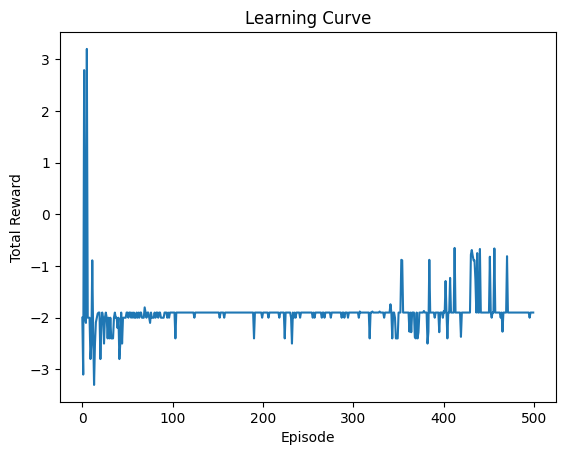

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

print (model.replay_buffer)
## plotting the learning curve
buffer = model.replay_buffer
rewards = buffer.rewards
dones = buffer.dones
# We need to reconstruct the episode rewards from the replay buffer, which only contains the reward for each step, not the total reward for each episode
episode_rewards = []
current_reward = 0
for r, d in zip(rewards, dones):
    current_reward += r
    if d:
        episode_rewards.append(current_reward)
        current_reward = 0
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curve")

plt.show()



In [98]:
max_reward = max(episode_rewards)
idx_maw_reward = episode_rewards.index(max_reward)
max_reward_episode = buffer.observations[idx_maw_reward]

def get_actions_from_episode(model, episode_idx):
    buffer = model.replay_buffer
    # On récupère toutes les données du buffer (jusqu'à la position actuelle)
    actions = buffer.actions[:buffer.pos]
    dones = buffer.dones[:buffer.pos]
    
    episodes = []
    current_episode_actions = []
    
    for i in range(len(actions)):
        current_episode_actions.append(int(actions[i][0][0]))
        if dones[i]:
            episodes.append(current_episode_actions)
            current_episode_actions = []
            
    if episode_idx >= len(episodes):
        print(f"Erreur : Le buffer ne contient que {len(episodes)} épisodes complets.")
        return None
        
    return episodes[episode_idx]

# Utilisation :
# episode_nb = 10 # Par exemple l'épisode 10
# actions_list = get_actions_from_episode(model, episode_nb)
# print(f"Actions de l'épisode {episode_nb} : {actions_list}")


def replay_recorded_episode(env, actions):
    obs, _ = env.reset()
    env.render()
    total_r = 0
    for a in actions:
        obs, r, done, truncated, info = env.step(a)
        total_r += r
        print(f"Action: {a}, Reward: {r}, Total Reward: {total_r}")
        env.render()
        if done: break
    print(f"Total Replay Reward: {total_r}")

# Exemple avec l'épisode ayant eu le max reward
best_actions = get_actions_from_episode(model, idx_maw_reward)
if best_actions:
    replay_recorded_episode(env, best_actions)


Erreur : Le buffer ne contient que 0 épisodes complets.


In [96]:
buffer = model.replay_buffer
actions = buffer.actions[:buffer.size()]
unique, counts = np.unique(actions, return_counts=True)
action_counts = dict(zip(unique, counts))
print("Action distribution in replay buffer:", action_counts)

Action distribution in replay buffer: {np.int64(0): np.int64(13167), np.int64(1): np.int64(10287), np.int64(2): np.int64(3823), np.int64(3): np.int64(25785), np.int64(4): np.int64(25990), np.int64(5): np.int64(20948)}


In [97]:
obs, _ = env.reset()

for _ in range(200):

    action, _ = model.predict(obs, deterministic=True)

    print("action:", action)

    obs, reward, done, truncated, info = env.step(action)
    print("reward:", reward)
    env.render()

    if done:
        break

action: 0
reward: -0.01

. . T . S . B . X
C   ^           P
.               .
.               V
. . . . D . . . .
Hand : None
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 1/200
action: 4
reward: 0.09000000000000001

. . T . S . B . X
C   ^           P
.               .
.               V
. . . . D . . . .
Hand : tomato
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps: 2/200
action: 3
reward: -0.01

. . T . S . B . X
C     >         P
.               .
.               V
. . . . D . . . .
Hand : tomato
Pans : [((8, 1), 'empty', 0)]
Dishes : [((4, 4), False, False, False)]
Chopping boards : [('chop_board_1', 0)]
Objects on counters : [((8, 1), 'pan_0'), ((4, 4), 'dish_0')]
Orders: 0 active
Steps